"""
Ce script a pour but l'automatisation complète de l'entraînement MobileNet.
L'utilisateur devra renseigner sa requête MySQL correspondant aux différentes classes directement dans le code puis lancer le script. Des paramètres par défaut sont conseillés.
A la fin, l'utilisateur aura des poids ainsi que l'historique des entraînements. Les résultats et le paramétrage seront fidèlement consignés dans la table `dataset`.
Pour retrouver le jeu de données, soit on lance de nouveau la requête avec une limite sur la date, soit on le retrouve grâce à la table de jointure `vignette_dataset`.
"""

import Cap_2020_custom_training_functions
from Cap_2020_custom_training_functions import *

In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

##############
# Bibliothèques { -------------------------------------------------------------------------------------------------------------------------------------------
##############
import time
import os, sys, shutil
import random
import matplotlib.pyplot as plt
#import mysql.connector
import traceback
import pandas as pd
import numpy as np
import cv2
from datetime import datetime
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from tensorflow.image import rgb_to_grayscale, rgb_to_hsv
from tensorflow.keras import backend
##############
# Bibliothèques } -------------------------------------------------------------------------------------------------------------------------------------------
##############

2026-01-20 16:42:59.617220: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-20 16:42:59.628601: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-20 16:43:00.090441: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-20 16:43:02.296306: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [7]:

for dirpath, dirnames, filenames in os.walk('/home/cytech/Desktop/python workspace/Ai4Industry/bdd'):
    if dirnames:
        print(f'Directory: {dirpath}')
        for d in dirnames:
            print(f'  Subdirectory: {d}')

Directory: /home/cytech/Desktop/python workspace/Ai4Industry/bdd
  Subdirectory: 0_thrips
  Subdirectory: AUTRES
Directory: /home/cytech/Desktop/python workspace/Ai4Industry/bdd/0_thrips
  Subdirectory: 2021_smartphone_quality
  Subdirectory: 2024_target_quality_VIV
  Subdirectory: 2021_low_quality
  Subdirectory: 2022_close_up
Directory: /home/cytech/Desktop/python workspace/Ai4Industry/bdd/AUTRES
  Subdirectory: 2021_smartphone_quality
  Subdirectory: 2024_target_quality_VIV
  Subdirectory: VID
  Subdirectory: cicadelle_VID
  Subdirectory: cicadelle_smartphone_quality
  Subdirectory: 2021_low_quality
  Subdirectory: 2022_close_up


In [ ]:
import os
import shutil
import random

# ATTENTION : BASE_DIR doit être différent de TRAIN_TEMP_DIR
# --- CONFIGURATION ---
BASE_DIR = '/home/cytech/Desktop/python workspace/Ai4Industry/bdd'
#choix des qualités à inclure qui sont les sous dossier des classes
QUALITIES_TO_INCLUDE = [
    '2021_low_quality',
    '2021_smartphone_quality',
    '2022_close_up',
    '2024_target_quality_VIV',
    '2021_low_quality',
    'cicadelle_VID',
    'cicadelle_smartphone_quality',
    '2022_close_up',
    '2021_smartphone_quality',
    'VID',
    '2024_target_quality_VIV'
]
TRAIN_TEMP_DIR = '/home/cytech/Desktop/python workspace/Ai4Industry/AI4I_2026_JDD_V0' # Le "folder" à donner à votre fonction
#les classes à inclure qui sont les dossiers dans BASE_DIR
CLASSES = ['0_thrips', 'AUTRES']
SPLIT_RATIO = 0.7  # 80% train, 20% validation

# --- NETTOYAGE ET CRÉATION DE LA STRUCTURE ---
if os.path.exists(TRAIN_TEMP_DIR):
    shutil.rmtree(TRAIN_TEMP_DIR)

for split in ['train', 'validation']:
    for category in CLASSES:
        os.makedirs(os.path.join(TRAIN_TEMP_DIR, split, category), exist_ok=True)

# --- RÉPARTITION DES IMAGES ---
for category in CLASSES:
    all_images = []
    # 1. Lister toutes les images des qualités choisies
    for quality in QUALITIES_TO_INCLUDE:
        source_path = os.path.join(BASE_DIR, category, quality)
        if os.path.exists(source_path):
            images = [os.path.join(source_path, f) for f in os.listdir(source_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            all_images.extend(images)

    # 2. Mélanger aléatoirement
    random.seed(123)
    random.shuffle(all_images)

    # 3. Séparer en Train et Validation
    split_idx = int(len(all_images) * SPLIT_RATIO)
    train_files = all_images[:split_idx]
    val_files = all_images[split_idx:]

    # 4. Créer les liens symboliques
    for img_path in train_files:
        dest = os.path.join(TRAIN_TEMP_DIR, 'train', category, os.path.basename(img_path))
        if os.path.exists(dest): # Add this check
            os.remove(dest)     # Remove existing file/link if any
        os.symlink(img_path, dest)

    for img_path in val_files:
        dest = os.path.join(TRAIN_TEMP_DIR, 'validation', category, os.path.basename(img_path))
        if os.path.exists(dest): # Add this check
            os.remove(dest)     # Remove existing file/link if any
        os.symlink(img_path, dest)

print(f"Structure prête dans {TRAIN_TEMP_DIR}")
print(f"Train : {len(train_files)} images | Validation : {len(val_files)} images")

Structure prête dans /home/cytech/Desktop/python workspace/Ai4Industry/AI4I_2026_JDD_V0
Train : 3409 images | Validation : 1461 images


Checking folder: /home/cytech/Desktop/python workspace/Ai4Industry/AI4I_2026_JDD_V0/train/0_thrips
Found 711 images in /home/cytech/Desktop/python workspace/Ai4Industry/AI4I_2026_JDD_V0/train/0_thrips
Image: ASTREDHOR_TPR_18-06_scan_4_transmis;757;777;688;708.png | Dossier source réel: /home/cytech/Desktop/python workspace/Ai4Industry/bdd/0_thrips/2021_low_quality/ASTREDHOR_TPR_18-06_scan_4_transmis;757;777;688;708.png
Image: ASTREDHOR_TPR_18-06_scan_2_transmis;487;502;296;311.png | Dossier source réel: /home/cytech/Desktop/python workspace/Ai4Industry/bdd/0_thrips/2021_low_quality/ASTREDHOR_TPR_18-06_scan_2_transmis;487;502;296;311.png
Image: ASTREDHOR_TPR_18-06_scan_4_transmis;832;852;338;358.png | Dossier source réel: /home/cytech/Desktop/python workspace/Ai4Industry/bdd/0_thrips/2021_low_quality/ASTREDHOR_TPR_18-06_scan_4_transmis;832;852;338;358.png
Checking folder: /home/cytech/Desktop/python workspace/Ai4Industry/AI4I_2026_JDD_V0/train/AUTRES
Found 2725 images in /home/cytech/De

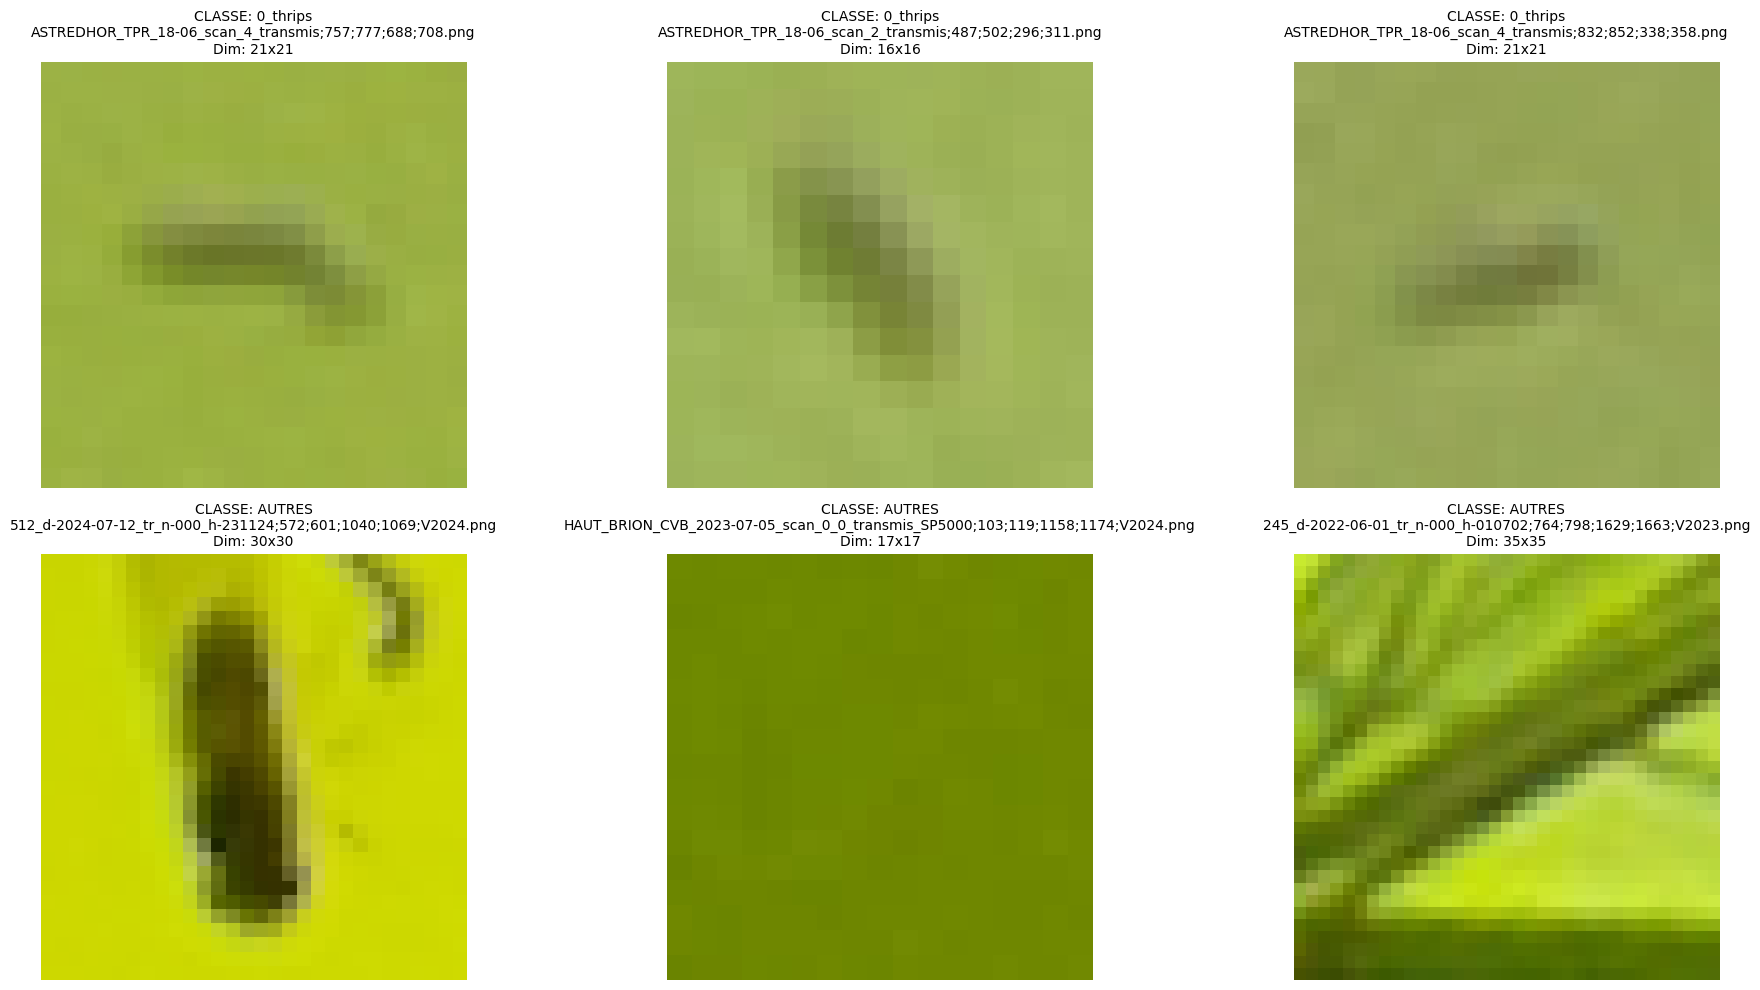

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

def visualiser_et_verifier_chemins(base_path, classes, n_images=3):
    # On agrandit la figure pour pouvoir lire les chemins
    plt.figure(figsize=(20, 10))

    for i, category in enumerate(classes):
        folder_path = os.path.join(base_path, 'train', category)
        print(f"Checking folder: {folder_path}") # Debug print

        if not os.path.exists(folder_path):
            print(f"Attention: Le dossier {folder_path} n'existe pas !")
            continue

        images = os.listdir(folder_path)
        print(f"Found {len(images)} images in {folder_path}") # Debug print

        if not images: # If no images, skip to next category
            print(f"No images found in {folder_path}. Skipping.")
            continue

        sample_images = random.sample(images, min(n_images, len(images)))

        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(folder_path, img_name)

            # Lecture de l'image
            img = mpimg.imread(img_path)

            # Affichage
            plt.subplot(len(classes), n_images, i * n_images + j + 1)
            plt.imshow(img, interpolation='none')

            # On affiche le nom du fichier et la taille réelle en pixels
            plt.title(f"CLASSE: {category}\n{img_name}\nDim: {img.shape[1]}x{img.shape[0]}", fontsize=10)
            plt.axis('off')

            # Print dans la console pour vérifier le dossier source du lien symbolique
            if os.path.islink(img_path):
                source_reelle = os.readlink(img_path)
                print(f"Image: {img_name} | Dossier source réel: {source_reelle}")
            else:
                print(f"Image: {img_name} | Not a symbolic link.") # Debug print

    plt.tight_layout()
    plt.show()

# Utilisation
visualiser_et_verifier_chemins(TRAIN_TEMP_DIR, CLASSES)

In [10]:
##############
# Fonctions { -------------------------------------------------------------------------------------------------------------------------------------------
##############
# def obtention_listes_nom_fichier_vignette(mysql_request):
#     """
#     En entrée la requête MySQL.
#     En sortie une liste de listes. Chacune contient des nom_fichier_vignette
#     """
#     try:
#         #Exécution de la requête
#         cnx     = mysql.connector.connect(user=BDD_USER, host=BDD_HOST, database=BDD_BRANCH, password=BDD_PASSWORD)
#         cursor  = cnx.cursor()
#         cursor.execute(mysql_request)
#         result  = cursor.fetchall()
#         cnx.close()

#         #Création du dictionnaire de vignettes
#         dictionnaire = [[] for i in range(nb_classes)]
#         for item in result:
#             dictionnaire[item[1]].append(item[0])

#         return dictionnaire

#     except Exception as e:
#         print("Erreur récupération listes nom_fichier_vignette")
#         print(traceback.format_exc())
#         return []


# def separation_entrainement_validation(buffer_validation, proportion_train, proportion_test, effectifs_train, effectifs_validation, effectifs_test, save_path_origin, save_path_dest):
#     """
#     En entrée une liste de listes. La fonction va alors séparer aléatoirement les vignettes en jeux de données train & validation selon un ratio renseigné par l'utilisateur.
#     Le ratio peut-être de 1/3 si les effectifs sont bien fournis, mais 1/4 ou 1/5 suffisent en général.


#     MAJ 2024 : Nouvelle répartition train/validation/test !
#     Un exemple de répartition typique serait 70% des vignettes pour l'entraînement, 20% pour la validation et enfin 10% du jeu de données totalement décorellé de l'entraînement pour vérifier les résultats à la fin.

#     Tout d'abord, pour chaque classe, on extrait du dictionnaire le nombre d'images voulues pour l'entraînement. Ce nombre est soit un pourcentage du nombre total de vignettes de la classe, soit un nombre fixé.
#     Dans le cas d'un nombre fixé, il faut prendre garde à laisser suffisamment d'image en validation et en test !

#     Ensuite, on extrait parmi les images restantes du dictionnaire celles qui iront dans le jeu de test final. Ce jeu de test n'est pas obligatoire.

#     Enfin les vignettes restantes vont aller dans le jeu de validation pour l'étape d'inférence de l'entraînement. On peut limiter les vignettes qui vont y aller s'il y en a bcp.
#     """
#     try:
#         #Suppression dossier de destination si pré-existant
#         if os.path.exists(save_path_dest) == True:
#             shutil.rmtree(save_path_dest, ignore_errors = True)

#         for i in range(nb_classes):
#             #Création dossier train
#             save_path_train = save_path_dest+"/train/"+classes[i]
#             if os.path.exists(save_path_train) == False:
#                 os.makedirs(save_path_train)
#             #Création dossier validation
#             save_path_validation = save_path_dest+"/validation/"+classes[i]
#             if os.path.exists(save_path_validation) == False:
#                 os.makedirs(save_path_validation)
#             #Création dossier test
#             if proportion_test != 0 or sum(effectifs_test) != 0:
#                 save_path_test = save_path_dest+"/test/"+classes[i]
#                 if os.path.exists(save_path_test) == False:
#                     os.makedirs(save_path_test)

#             len_class = len(buffer_validation[i])
#             print("len_class=",len_class)
#             buffer_train, buffer_test = [], []

#             #Sélection aléatoire des vignettes pour l'entraînement
#             if effectifs_train[i] == 0:
#                 for j in range(round(proportion_train*len_class)):
#                     a = random.choice(range(len(buffer_validation[i])))
#                     buffer_train.append(buffer_validation[i][a])
#                     buffer_validation[i].remove(buffer_validation[i][a])
#             else:
#                 while len(buffer_train)<effectifs_train[i]:
#                     a = random.choice(range(len(buffer_validation[i])))
#                     buffer_train.append(buffer_validation[i][a])
#                     buffer_validation[i].remove(buffer_validation[i][a])

#             #Sélection aléatoire des vignettes pour le test
#             if proportion_test != 0 or sum(effectifs_test) != 0:
#                 if effectifs_test[i] == 0:
#                     for j in range(round(proportion_test*len_class)):
#                         a = random.choice(range(len(buffer_validation[i])))
#                         buffer_test.append(buffer_validation[i][a])
#                         buffer_validation[i].remove(buffer_validation[i][a])
#                 else:
#                     while len(buffer_test)<effectifs_test[i]:
#                         a = random.choice(range(len(buffer_validation[i])))
#                         buffer_test.append(buffer_validation[i][a])
#                         buffer_validation[i].remove(buffer_validation[i][a])

#             #Suppression aléatoire des vignettes pour limiter vignettes en validation : à combiner avec effectifs_train
#             if effectifs_train[i] != 0 and effectifs_validation[i] != 0:
#                 for j in range(len_class-effectifs_train[i]-effectifs_validation[i]-effectifs_test[i]):
#                     a = random.choice(range(len(buffer_validation[i])))
#                     buffer_validation[i].remove(buffer_validation[i][a])

#             file_3 = open(FOLDER_SAVE+"/JDD_"+id+".txt",'a+')
#             #Les images sont finalement copiées
#             file_3.write("train\n")
#             for j in range(len(buffer_train)):
#                 file_3.write("%s\n"%buffer_train[j])
#                 shutil.copyfile(save_path_origin+"/"+buffer_train[j], save_path_train+"/"+buffer_train[j])
#             file_3.write("validation\n")
#             for j in range(len(buffer_validation[i])):
#                 file_3.write("%s\n"%buffer_validation[i][j])
#                 shutil.copyfile(save_path_origin+"/"+buffer_validation[i][j], save_path_validation+"/"+buffer_validation[i][j])
#             if proportion_test != 0 or sum(effectifs_test) != 0:
#                 file_3.write("test\n")
#                 for j in range(len(buffer_test)):
#                     file_3.write("%s\n"%buffer_test[j])
#                     shutil.copyfile(save_path_origin+"/"+buffer_test[j], save_path_test+"/"+buffer_test[j])
#             file_3.write("\n")
#             file_3.close

#     except Exception as e:
#         print("Erreur création des dossiers pour l'apprentissage")
#         print(traceback.format_exc())

def random_red_offset(img, offset_range):
    r,g,b = cv2.split(img)
    offset=random.choice(range(-offset_range,offset_range+1,1))
    r=r+offset
    img=cv2.merge((r,g,b))
    del r, g, b
    return img
def random_green_offset(img, offset_range):
    r,g,b = cv2.split(img)
    offset=random.choice(range(-offset_range,offset_range+1,1))
    g=g+offset
    img=cv2.merge((r,g,b))
    del r, g, b
    return img
def random_blue_offset(img, offset_range):
    r,g,b = cv2.split(img)
    offset=random.choice(range(-offset_range,offset_range+1,1))
    b=b+offset
    img=cv2.merge((r,g,b))
    del r, g, b
    return img
def preprocessing_function_1(img):
    offset_range=20
    img = random_red_offset(img, offset_range)
    img = random_green_offset(img, offset_range)
    img = random_blue_offset(img, offset_range)
    return preprocess_input(img)

def preprocessing_function_2(img):
    img_gray=rgb_to_grayscale(img)
    img=np.repeat(img_gray, 3, axis=-1)
    del img_gray
    return preprocess_input(img)

def data_augmentation_vignettes_train(coef, save_path_dest):
    """
    Chacune des vignettes du dossier d'entraînement permet d'en créer de nouvelles en lui appliquant des transformations géométriques.
    Si le coefficient de multiplication est de 2, une seule vignette sera créée avec chacune des vignettes d'origine. Si le coefficient est de 3, 2 nouvelles vignettes, et ainsi de suite.
    Si le coefficient est de 0 ou 1, cette fonction ne sera simplement pas lancée.
    """
    try:
        #Définition des transformations aléatoires appliquées à la vignette
        datagen = ImageDataGenerator(
                rotation_range=90,
                # brightness_range=(0.9,1.1),
                width_shift_range=0.1,
                height_shift_range=0.1,
                shear_range=10,
                horizontal_flip=True,
                vertical_flip=True)

        for i in range(nb_classes):
            #Récupération du chemin des vignettes
            save_path_train = save_path_dest+"/train/"+classes[i]
            vignettes = os.listdir(save_path_train)
            vignettes = [save_path_train+"/"+vignettes[i] for i in range(len(vignettes))]

            for j in range(len(vignettes)):
                x = plt.imread(vignettes[j])
                x = x.reshape((1,)+x.shape)
                k = 1
                #Création de vignettes
                for batch in datagen.flow(x, batch_size=1, save_prefix=str(j), save_to_dir=save_path_train):
                    k+=1
                    if k==coef:
                        break

    except Exception as e:
        print("Erreur data-augmentation du dossier d'apprentissage")
        print(traceback.format_exc())


def entrainement_mobilenet(folder, nb_epochs, save_path, id):
    """
    MobileNet - https://arxiv.org/abs/1704.04861
    Les couches de sortie sont une simple transposition de l'architecture initiale, dédiée à ImageNet (1000 neurones de sortie), à notre cas d'utilisation (nb_classes neurones de sortie).
    La fonction d'optimisation est l'algorithme de descente stochastique de gradient SGD(lr=1e-4, momentum=0.9). Les fonctions SGD(lr=10e-3), Adagrad et Adadelta ont également données de bons résultats.
    Les meilleurs poids selon l'accuracy et le loss sont sauvegardés, ainsi que l'historique de l'entraînement.
    """
    try:
        #Définition du modèle
        model     = MobileNet(weights='imagenet', include_top=False, input_shape=(128,128,3))
        x         = model.output
        x         = GlobalAveragePooling2D()(x)
        x         = Dense(1024,activation='relu')(x)
        sortie    = Dense(nb_classes, activation='softmax')(x)
        mobilenet = Model(inputs=model.input, outputs=sortie)
        del model, x, sortie

        #Pré-processing des vignettes
        validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
        # validation_datagen = ImageDataGenerator(preprocessing_function=preprocessing_function_1)
        # validation_datagen = ImageDataGenerator(preprocessing_function=preprocessing_function_2)

        if FLAG_DA == 0:
            train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
            # train_datagen = ImageDataGenerator(preprocessing_function=preprocessing_function_1)
            # train_datagen = ImageDataGenerator(preprocessing_function=preprocessing_function_2)
        else:
            train_datagen = ImageDataGenerator(
                preprocessing_function=preprocess_input,
                # preprocessing_function=preprocessing_function_1,
                # preprocessing_function=preprocessing_function_2,
                rotation_range=90,
                brightness_range=(0.95,1.05),
                width_shift_range=0.1,
                height_shift_range=0.1,
                shear_range=10,
                horizontal_flip=True,
                vertical_flip=True)

        #Création des batchs d'entraînement et de validation
        train_generator = train_datagen.flow_from_directory(folder+"/train", color_mode='rgb', batch_size=32, target_size=(128,128), class_mode='categorical', shuffle=True)
        validation_generator  = validation_datagen.flow_from_directory(folder+"/validation", color_mode='rgb', batch_size=32, target_size=(128,128), class_mode='categorical', shuffle=False)

        #Compilation du modèle
        mobilenet.compile(loss='categorical_crossentropy',optimizer=SGD(learning_rate=1e-4, momentum=0.9),metrics=['accuracy'])

        #Création de points de sauvegarde
        now             = datetime.now()
        time            = now.strftime("%Y-%m-%d_%H%M%S")
        best_accuracy = "best_accuracy_" + id + "(" + time + ").weights.h5"
        best_loss     = "best_loss_" + id + "(" + time + ").weights.h5"
        checkpoint_loss = ModelCheckpoint(save_path+"/"+best_loss, monitor='val_loss', save_best_only=True, save_weights_only=True, mode='min')#, save_freq='epoch')
        # checkpoint_acc  = ModelCheckpoint(save_path+"/"+best_accuracy, monitor='val_accuracy', save_best_only=True, save_weights_only=True, mode='max')#, save_freq='epoch')

        #Entraînement du modèle
        step_size_train=train_generator.n//train_generator.batch_size
        step_size_validation =validation_generator.n//validation_generator.batch_size
        history = mobilenet.fit(
            x=train_generator,
            steps_per_epoch=step_size_train,
            validation_data=validation_generator,
            validation_steps=step_size_validation,
            epochs=nb_epochs,
            verbose=2,
            callbacks=[checkpoint_loss])
            # callbacks=[checkpoint_acc, checkpoint_loss])

        del mobilenet
        backend.clear_session()

        #Sauvegarde de l'historique de l'entraînement
        hist_df   = pd.DataFrame(history.history)
        hist_file = "history_"+str(id)+"("+time+").csv"
        with open(save_path+"/"+hist_file, mode='w') as f:
            hist_df.to_csv(f)

        return best_accuracy, best_loss, hist_file

    except Exception as e:
        print("Erreur entraînement de MobileNet")
        print(traceback.format_exc())
        return 'None', 'None', 'None'


def analyse_affectations_mobilenet_validation(folder, save_path, weights, history):
    """
    Cette fonction charge d'abord le modèle MobileNet avec les poids issus de l'entrainement, puis réalise des prédictions sur toutes les vignettes du jeu de validation.
    Pour affecter une classe à une vignette, on prend simplement celle pour laquelle la valeur prédite est la plus élevée.
    On obtient alors la matrice de confusion représentant ces classifications, d'où l'on tire la précision, le rappel et la moyenne harmonique par classe. La moyenne de ces trois métriques est réalisée.
    En sortie,
    """
    try:
        # print("Définition du modèle")
        #Définition du modèle
        model     = MobileNet(weights=None, include_top=False, input_shape=(128,128,3))
        x         = model.output
        x         = GlobalAveragePooling2D()(x)
        x         = Dense(1024,activation='relu')(x)
        sortie    = Dense(nb_classes, activation='softmax')(x)
        mobilenet = Model(inputs=model.input, outputs=sortie)
        del model, x, sortie
        mobilenet.load_weights(save_path+"/"+weights)

        # print("Prédictions jeu validation")
        #Calcul de toutes les prédictions
        nb_vignettes        = []
        result_mobilenet    = []
        for i in range(nb_classes):
            result_classe   = []
            vignettes       = os.listdir(folder+'/validation/'+classes[i])
            nb_vignettes.append(len(vignettes))
            for j in range(nb_vignettes[i]):
                # img_pil     = load_img(folder+'/validation/'+classes[i]+'/'+vignettes[j], target_size=(128, 128), color_mode='grayscale')
                img_pil     = load_img(folder+'/validation/'+classes[i]+'/'+vignettes[j], target_size=(128, 128))
                img_array   = img_to_array(img_pil)
                # img_array   = np.repeat(img_array, 3, axis=-1)
                img_batch   = np.expand_dims(img_array, axis=0)
                img_preprocessed = preprocess_input(img_batch)
                prediction  = mobilenet.predict(img_preprocessed, verbose=0)
                result_classe.append(prediction[0])
            result_mobilenet.append(result_classe)

        del mobilenet
        backend.clear_session()

        # file_2 = open(FOLDER_SAVE+"/"+"Erreurs_"+id+".txt", 'a+')
        # file_2.write("                                                                                                                                                                                                    \n")
        # file_2.close

        # print("Calcul confusion")
        #Création de la matrice de confusion
        confusion = np.zeros((nb_classes, nb_classes), dtype=int)
        for i in range(nb_classes):
            vignettes  = os.listdir(folder+'/validation/'+classes[i])
            for j in range(nb_vignettes[i]):
                index_max_value = np.argmax(result_mobilenet[i][j])
                if index_max_value == i:
                    confusion[i][i]+=1 #Vrai positif
                else:
                    confusion[i][index_max_value]+=1
                    # file_2 = open(FOLDER_SAVE+"/"+"Erreurs_"+id+".txt", 'a+')
                    # file_2.write("%s,%s,%s,%s,%s\n" % (vignettes[j], classes[index_max_value], result_mobilenet[i][j][index_max_value], classes[i], result_mobilenet[i][j][i]))
                    # file_2.close

        # print("Calcul précision/rappel/F-mesure")
        #Calcul de la précision, du rappel et de la F-mesure
        result_classe = np.zeros((nb_classes, 3), dtype=float)
        for j in range(nb_classes):
            #Précision/accuracy
            s = 0
            for i in range(nb_classes):
                s+=confusion[i][j]
            acc = confusion[j][j]/s
            result_classe[j][0] = round(acc*100,1)
            print("Précision de la classe %s : %s%%" % (j, round(acc*100,1)))
            #Recall/rappel
            rec = confusion[j][j]/sum(confusion[j])
            result_classe[j][1] = round(rec*100,1)
            print("Rappel de la classe %s : %s%%" % (j, round(rec*100,1)))
            #F-mesure
            fm = 2*acc*rec/(acc+rec)
            result_classe[j][2] = round(fm*100,1)
            print("Moyenne harmonique de la classe %s : %s%%" % (j, round(fm*100,1)))

        #Moyenne de la précision, du rappel et de la F-mesure
        s0, s1, s2 = 0, 0, 0
        for i in range(nb_classes):
            s0+=result_classe[i][0]
            s1+=result_classe[i][1]
            s2+=result_classe[i][2]
        result_moyenne = np.array([round(s0/nb_classes,1), round(s1/nb_classes,1), round(s2/nb_classes,1)])

        #Enfin, on récupère val_accuracy et val_loss dans history.csv. NB : méthode sous-optimal car ce serait mieux lors de l'entraînement, mais qui fonctionne bien.
        with open(save_path+"/"+history) as file_name:
            array_history = np.loadtxt(file_name, delimiter=",", skiprows=1)
        val_accuracy, val_loss = np.amax(array_history, axis=0)[4], np.amin(array_history, axis=0)[3]

        return str(confusion), str(result_classe), str(result_moyenne), str(round(val_accuracy,3)), str(round(val_loss,3))

    except Exception as e:
        print("Erreur inférence sur jeu de validation")
        print(traceback.format_exc())
        return 'None', 'None', 'None', 'None', 'None'



def analyse_affectations_mobilenet_test(folder, save_path, weights):
    try:
        # print("Définition du modèle")
        #Définition du modèle
        model     = MobileNet(weights=None, include_top=False, input_shape=(128,128,3))
        x         = model.output
        x         = GlobalAveragePooling2D()(x)
        x         = Dense(1024,activation='relu')(x)
        sortie    = Dense(nb_classes, activation='softmax')(x)
        mobilenet = Model(inputs=model.input, outputs=sortie)
        del model, x, sortie
        mobilenet.load_weights(save_path+"/"+weights)

        # print("Prédictions jeu test")
        #Calcul de toutes les prédictions
        nb_vignettes        = []
        result_mobilenet    = []
        for i in range(nb_classes):
            result_classe   = []
            vignettes       = os.listdir(folder+'/test/'+classes[i])
            nb_vignettes.append(len(vignettes))
            for j in range(nb_vignettes[i]):
                # img_pil     = load_img(folder+'/test/'+classes[i]+'/'+vignettes[j], target_size=(128, 128), color_mode='grayscale')
                img_pil     = load_img(folder+'/test/'+classes[i]+'/'+vignettes[j], target_size=(128, 128))
                img_array   = img_to_array(img_pil)
                # img_array   = np.repeat(img_array, 3, axis=-1)
                img_batch   = np.expand_dims(img_array, axis=0)
                img_preprocessed = preprocess_input(img_batch)
                prediction  = mobilenet.predict(img_preprocessed, verbose=0)
                result_classe.append(prediction[0])
            result_mobilenet.append(result_classe)

        del mobilenet
        backend.clear_session()

        file_2 = open(FOLDER_SAVE+"/"+"Erreurs_"+id+".txt", 'a+')
        file_2.write("                                                                                                                                                                                                    \n")
        file_2.close

        # print("Calcul confusion")
        #Création de la matrice de confusion
        confusion = np.zeros((nb_classes, nb_classes), dtype=int)
        for i in range(nb_classes):
            vignettes  = os.listdir(folder+'/test/'+classes[i])
            for j in range(nb_vignettes[i]):
                index_max_value = np.argmax(result_mobilenet[i][j])
                if index_max_value == i:
                    confusion[i][i]+=1 #Vrai positif
                else:
                    confusion[i][index_max_value]+=1
                    file_2 = open(FOLDER_SAVE+"/"+"Erreurs_"+id+".txt", 'a+')
                    file_2.write("%s,%s,%s,%s,%s\n" % (vignettes[j], classes[index_max_value], result_mobilenet[i][j][index_max_value], classes[i], result_mobilenet[i][j][i]))
                    file_2.close

        # print("Calcul précision/rappel/F-mesure")
        #Calcul de la précision, du rappel et de la F-mesure
        result_classe = np.zeros((nb_classes, 3), dtype=float)
        for j in range(nb_classes):
            #Précision/accuracy
            s = 0
            for i in range(nb_classes):
                s+=confusion[i][j]
            acc = confusion[j][j]/s
            result_classe[j][0] = round(acc*100,1)
            print("Précision de la classe %s : %s%%" % (j, round(acc*100,1)))
            #Recall/rappel
            rec = confusion[j][j]/sum(confusion[j])
            result_classe[j][1] = round(rec*100,1)
            print("Rappel de la classe %s : %s%%" % (j, round(rec*100,1)))
            #F-mesure
            fm = 2*acc*rec/(acc+rec)
            result_classe[j][2] = round(fm*100,1)
            print("Moyenne harmonique de la classe %s : %s%%" % (j, round(fm*100,1)))

        #Moyenne de la précision, du rappel et de la F-mesure
        s0, s1, s2 = 0, 0, 0
        for i in range(nb_classes):
            s0+=result_classe[i][0]
            s1+=result_classe[i][1]
            s2+=result_classe[i][2]
        result_moyenne = np.array([round(s0/nb_classes,1), round(s1/nb_classes,1), round(s2/nb_classes,1)])


        # print("Idem seuil de décision = 0.5")
        seuil_ia=0.5
        confusion_05 = np.zeros((nb_classes, nb_classes), dtype=int)
        for i in range(nb_classes):
            vignettes  = os.listdir(folder+'/test/'+classes[i])
            for j in range(nb_vignettes[i]):
                index_max_value = np.argmax(result_mobilenet[i][j])
                if index_max_value == nb_classes-1: #Cas autres : on va exiger que la valeur de la prédiction soit supérieur à un certains seuil de décision ; sinon on sauve la vignette des autres
                    if result_mobilenet[i][j][index_max_value]>seuil_ia:
                        confusion_05[i][index_max_value]+=1 #Vrai positif
                    else:
                        temp_tab=result_mobilenet[i][j]
                        temp_tab[index_max_value]=0
                        index_max_value = np.argmax(temp_tab)
                        confusion_05[i][index_max_value]+=1
                else:
                    confusion_05[i][index_max_value]+=1
        result_classe_05 = np.zeros((nb_classes, 3), dtype=float)
        for j in range(nb_classes):
            s = 0
            for i in range(nb_classes):
                s+=confusion_05[i][j]
            acc = confusion_05[j][j]/s
            result_classe_05[j][0] = round(acc*100,1)
            rec = confusion_05[j][j]/sum(confusion_05[j])
            result_classe_05[j][1] = round(rec*100,1)
            fm = 2*acc*rec/(acc+rec)
            result_classe_05[j][2] = round(fm*100,1)
        s0, s1, s2 = 0, 0, 0
        for i in range(nb_classes):
            s0+=result_classe_05[i][0]
            s1+=result_classe_05[i][1]
            s2+=result_classe_05[i][2]
        result_moyenne_05 = np.array([round(s0/nb_classes,1), round(s1/nb_classes,1), round(s2/nb_classes,1)])
        # print("Idem seuil de décision = 0.6")
        seuil_ia=0.6
        confusion_06 = np.zeros((nb_classes, nb_classes), dtype=int)
        for i in range(nb_classes):
            vignettes  = os.listdir(folder+'/test/'+classes[i])
            for j in range(nb_vignettes[i]):
                index_max_value = np.argmax(result_mobilenet[i][j])
                if index_max_value == nb_classes-1: #Cas autres : on va exiger que la valeur de la prédiction soit supérieur à un certains seuil de décision ; sinon on sauve la vignette des autres
                    if result_mobilenet[i][j][index_max_value]>seuil_ia:
                        confusion_06[i][index_max_value]+=1 #Vrai positif
                    else:
                        temp_tab=result_mobilenet[i][j]
                        temp_tab[index_max_value]=0
                        index_max_value = np.argmax(temp_tab)
                        confusion_06[i][index_max_value]+=1
                else:
                    confusion_06[i][index_max_value]+=1
        result_classe_06 = np.zeros((nb_classes, 3), dtype=float)
        for j in range(nb_classes):
            s = 0
            for i in range(nb_classes):
                s+=confusion_06[i][j]
            acc = confusion_06[j][j]/s
            result_classe_06[j][0] = round(acc*100,1)
            rec = confusion_06[j][j]/sum(confusion_06[j])
            result_classe_06[j][1] = round(rec*100,1)
            fm = 2*acc*rec/(acc+rec)
            result_classe_06[j][2] = round(fm*100,1)
        s0, s1, s2 = 0, 0, 0
        for i in range(nb_classes):
            s0+=result_classe_06[i][0]
            s1+=result_classe_06[i][1]
            s2+=result_classe_06[i][2]
        result_moyenne_06 = np.array([round(s0/nb_classes,1), round(s1/nb_classes,1), round(s2/nb_classes,1)])
        # print("Idem seuil de décision = 0.7")
        seuil_ia=0.7
        confusion_07 = np.zeros((nb_classes, nb_classes), dtype=int)
        for i in range(nb_classes):
            vignettes  = os.listdir(folder+'/test/'+classes[i])
            for j in range(nb_vignettes[i]):
                index_max_value = np.argmax(result_mobilenet[i][j])
                if index_max_value == nb_classes-1: #Cas autres : on va exiger que la valeur de la prédiction soit supérieur à un certains seuil de décision ; sinon on sauve la vignette des autres
                    if result_mobilenet[i][j][index_max_value]>seuil_ia:
                        confusion_07[i][index_max_value]+=1 #Vrai positif
                    else:
                        temp_tab=result_mobilenet[i][j]
                        temp_tab[index_max_value]=0
                        index_max_value = np.argmax(temp_tab)
                        confusion_07[i][index_max_value]+=1
                else:
                    confusion_07[i][index_max_value]+=1
        result_classe_07 = np.zeros((nb_classes, 3), dtype=float)
        for j in range(nb_classes):
            s = 0
            for i in range(nb_classes):
                s+=confusion_07[i][j]
            acc = confusion_07[j][j]/s
            result_classe_07[j][0] = round(acc*100,1)
            rec = confusion_07[j][j]/sum(confusion_07[j])
            result_classe_07[j][1] = round(rec*100,1)
            fm = 2*acc*rec/(acc+rec)
            result_classe_07[j][2] = round(fm*100,1)
        s0, s1, s2 = 0, 0, 0
        for i in range(nb_classes):
            s0+=result_classe_07[i][0]
            s1+=result_classe_07[i][1]
            s2+=result_classe_07[i][2]
        result_moyenne_07 = np.array([round(s0/nb_classes,1), round(s1/nb_classes,1), round(s2/nb_classes,1)])
        # print("Idem seuil de décision = 0.8")
        seuil_ia=0.8
        confusion_08 = np.zeros((nb_classes, nb_classes), dtype=int)
        for i in range(nb_classes):
            vignettes  = os.listdir(folder+'/test/'+classes[i])
            for j in range(nb_vignettes[i]):
                index_max_value = np.argmax(result_mobilenet[i][j])
                if index_max_value == nb_classes-1: #Cas autres : on va exiger que la valeur de la prédiction soit supérieur à un certains seuil de décision ; sinon on sauve la vignette des autres
                    if result_mobilenet[i][j][index_max_value]>seuil_ia:
                        confusion_08[i][index_max_value]+=1 #Vrai positif
                    else:
                        temp_tab=result_mobilenet[i][j]
                        temp_tab[index_max_value]=0
                        index_max_value = np.argmax(temp_tab)
                        confusion_08[i][index_max_value]+=1
                else:
                    confusion_08[i][index_max_value]+=1
        result_classe_08 = np.zeros((nb_classes, 3), dtype=float)
        for j in range(nb_classes):
            s = 0
            for i in range(nb_classes):
                s+=confusion_08[i][j]
            acc = confusion_08[j][j]/s
            result_classe_08[j][0] = round(acc*100,1)
            rec = confusion_08[j][j]/sum(confusion_08[j])
            result_classe_08[j][1] = round(rec*100,1)
            fm = 2*acc*rec/(acc+rec)
            result_classe_08[j][2] = round(fm*100,1)
        s0, s1, s2 = 0, 0, 0
        for i in range(nb_classes):
            s0+=result_classe_08[i][0]
            s1+=result_classe_08[i][1]
            s2+=result_classe_08[i][2]
        result_moyenne_08 = np.array([round(s0/nb_classes,1), round(s1/nb_classes,1), round(s2/nb_classes,1)])
        # print("Idem seuil de décision = 0.9")
        seuil_ia=0.9
        confusion_09 = np.zeros((nb_classes, nb_classes), dtype=int)
        for i in range(nb_classes):
            vignettes  = os.listdir(folder+'/test/'+classes[i])
            for j in range(nb_vignettes[i]):
                index_max_value = np.argmax(result_mobilenet[i][j])
                if index_max_value == nb_classes-1: #Cas autres : on va exiger que la valeur de la prédiction soit supérieur à un certains seuil de décision ; sinon on sauve la vignette des autres
                    if result_mobilenet[i][j][index_max_value]>seuil_ia:
                        confusion_09[i][index_max_value]+=1 #Vrai positif
                    else:
                        temp_tab=result_mobilenet[i][j]
                        temp_tab[index_max_value]=0
                        index_max_value = np.argmax(temp_tab)
                        confusion_09[i][index_max_value]+=1
                else:
                    confusion_09[i][index_max_value]+=1
        result_classe_09 = np.zeros((nb_classes, 3), dtype=float)
        for j in range(nb_classes):
            s = 0
            for i in range(nb_classes):
                s+=confusion_09[i][j]
            acc = confusion_09[j][j]/s
            result_classe_09[j][0] = round(acc*100,1)
            rec = confusion_09[j][j]/sum(confusion_09[j])
            result_classe_09[j][1] = round(rec*100,1)
            fm = 2*acc*rec/(acc+rec)
            result_classe_09[j][2] = round(fm*100,1)
        s0, s1, s2 = 0, 0, 0
        for i in range(nb_classes):
            s0+=result_classe_09[i][0]
            s1+=result_classe_09[i][1]
            s2+=result_classe_09[i][2]
        result_moyenne_09 = np.array([round(s0/nb_classes,1), round(s1/nb_classes,1), round(s2/nb_classes,1)])

        return str(confusion), str(result_classe), str(result_moyenne), str(confusion_05), str(result_classe_05), str(result_moyenne_05), str(confusion_06), str(result_classe_06), str(result_moyenne_06), str(confusion_07), str(result_classe_07), str(result_moyenne_07), str(confusion_08), str(result_classe_08), str(result_moyenne_08), str(confusion_09), str(result_classe_09), str(result_moyenne_09)
    except Exception as e:
        print("Erreur inférence sur jeu de test")
        print(traceback.format_exc())
        return 'None', 'None', 'None'


# def remplissage_table_dataset(libelle, classes, nombre_classes, requete, max_val_accuracy, min_val_loss, matrice_confusion, performances_par_classe, performances_moyenne, noms_poids, ratio_train_test, coef_da_1, flag_da_2, nombre_entrainements, nb_epochs, flag_travail):
#     """
#     Pour garder trace de cet entraînement, tout est systématiquement compilé dans la base de données.
#     """
#     try:
#         #Données à entrer
#         data_dataset = [libelle, classes, nombre_classes, requete, max_val_accuracy, min_val_loss, matrice_confusion, performances_par_classe, performances_moyenne, noms_poids, ratio_train_test, coef_da_1, flag_da_2, nombre_entrainements, nb_epochs, flag_travail]
#         #Exécution de la requête
#         cnx         = mysql.connector.connect(user=BDD_USER, host=BDD_HOST, database=BDD_BRANCH, password=BDD_PASSWORD)
#         cursor      = cnx.cursor()
#         add_dataset = ("INSERT INTO dataset (libelle, classes, nombre_classes, requete, max_val_accuracy, min_val_loss, matrice_confusion, performances_par_classe, performances_moyenne, noms_poids, ratio_train_test, coef_da_1, flag_da_2, nombre_entrainements, nombre_epochs, flag_travail) "
#                        "VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)")
#         cursor.execute(add_dataset, data_dataset)
#         cnx.commit()
#         cnx.close()

#     except Exception as e:
#         print("Erreur remplissage des données de la table `dataset`")
#         print(traceback.format_exc())


# def creation_table_jointure_vignette_dataset(dictionnaire):
#     """
#     Pour finir, on associe en base de données toutes les vignettes utilisées au dataset créé précédemment, en retenant la classe.
#     """
#     try:
#         #Connexion base de données
#         cnx    = mysql.connector.connect(user=BDD_USER, host=BDD_HOST, database=BDD_BRANCH, password=BDD_PASSWORD)
#         cursor = cnx.cursor()
#         #Récupération identifiant du dernier dataset
#         request_id = "SELECT max(id_dataset) FROM dataset"
#         cursor.execute(request_id)
#         id_dataset = cursor.fetchall()

#         #Association vignettes -> dataset
#         add_vignette_dataset = ("INSERT INTO vignette_dataset (nom_fichier_vignette, id_dataset, classe) "
#                                 "VALUES (%s, %s, %s)")
#         for i in range(nb_classes):
#             for j in range(len(dictionnaire[i])):
#                 data_vignette_dataset = [dictionnaire[i][j], id_dataset[0][0], classes[i]]
#                 cursor.execute(add_vignette_dataset, data_vignette_dataset)
#         cnx.commit()
#         cnx.close()

#     except Exception as e:
#         print("Erreur création de la table de jointure `vignette_dataset`")
#         print(traceback.format_exc())

##############
# Fonctions } -------------------------------------------------------------------------------------------------------------------------------------------
##############

In [11]:
import matplotlib.pyplot as plt

def plot_history(history_file, save_path):
    """
    Génère des graphiques de perte (loss) et de précision (accuracy)
    à partir du fichier CSV de l'historique.
    """
    df = pd.read_csv(os.path.join(save_path, history_file))

    plt.figure(figsize=(12, 4))

    # Graphique de l'Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(df['accuracy'], label='Train Accuracy')
    plt.plot(df['val_accuracy'], label='Val Accuracy')
    plt.title('Précision (Accuracy)')
    plt.xlabel('Époques')
    plt.legend()

    # Graphique de la Perte (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(df['loss'], label='Train Loss')
    plt.plot(df['val_loss'], label='Val Loss')
    plt.title('Perte (Loss)')
    plt.xlabel('Époques')
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(save_path, history_file.replace('.csv', '.png')))
    plt.show()

In [12]:
def sauvegarde_suivi_local(save_path, id, metrics_dict):
    """
    Remplace la base de données par un fichier texte récapitulatif.
    """
    suivi_file = os.path.join(save_path, f"recap_entrainement_{id}.txt")
    with open(suivi_file, 'a+') as f:
        f.write(f"\n--- Entraînement ID: {id} ({datetime.now()}) ---\n")
        for key, value in metrics_dict.items():
            f.write(f"{key}: {value}\n")
        f.write("-" * 50 + "\n")
    print(f"--> Suivi enregistré dans : {suivi_file}")

##############
# Obtention du paramétrage utilisateur { -------------------------------------------------------------------------------------------------------------------------------------------
##############
"""
Modèle :    $sudo python script_automatisation_entrainement.py FOLDER_SAVE libelle id nb_epochs iterations ratio coef FLAG_DA

De base : $sudo python script_automatisation_entrainement.py FOLDER_SAVE tordeuse tordeuse 100 3 0.25 0 1
    Ici on réalise 100 epochs avec une data-augmentation directement effectuée sur les batchs de vignettes d'entraînement.
    L'entraînement est réalisé 3 fois, et à chaque fois 1/4 du jeu de données est sélectionné aléatoirement pour la validation.
"""
ROOT_FOLDER=r"./Travail_IA"
libelle     = "TEST_VIGNE_2024-02-13"
FOLDER_SAVE = ROOT_FOLDER+"/"+libelle
id          = libelle
nb_epochs   = 10
iterations  = 2
ratio       = 0.3
coef        = 0
FLAG_DA     = 1

if coef == 1: coef == 0
if os.path.exists(FOLDER_SAVE) == False:
    os.makedirs(FOLDER_SAVE)

##############
# Paramétrage statique { -------------------------------------------------------------------------------------------------------------------------------------------
##############
"""
En général statique donc à modifier seulement si l'environnement de travail change.
"""
import config_bdd
from config_bdd import *
#Chemin d'origine des vignettes stockées sur un disque dur
FOLDER_IN  = "/tf-julien/VIGNETTE"
#Stockage temporaire des jeux de données d'entraînement
FOLDER_OUT = ROOT_FOLDER+"/FOLDER_OUT"  
##############
# Paramétrage statique } -------------------------------------------------------------------------------------------------------------------------------------------
##############

##############
# Requête MySQL initiale { -------------------------------------------------------------------------------------------------------------------------------------------
##############
"""
La toute première requête permet de récupérer un tableau contenant pour chacune des classes une liste de nom_fichier_vignette. Cette requête est l'étape cruciale à définir par l'utilisateur.
Prière d'indiquer les classes attendus : permet d'obtenir le nombre de classes et de nommer les dossiers. Les 0, 1 et 2 sont aussi nécessaires pour créer le dictionnaire.
/!\ il faut que les noms des classes soit dans l'ordre alphanumérique.
"""
classes       = ['0_eudemis','1_cochylis','2_crypto','AUTRES']
nb_classes    = len(classes)
mysql_request = ("""
SELECT vignette.nom_fichier_vignette,0 FROM vignette_label JOIN(vignette JOIN image ON vignette.nom_fichier_image=image.nom_fichier_image)ON vignette.nom_fichier_vignette=vignette_label.nom_fichier_vignette WHERE id_label IN(1) AND num_piege NOT IN('210','129','247','257')
UNION SELECT vignette.nom_fichier_vignette,1 FROM vignette_label JOIN(vignette JOIN image ON vignette.nom_fichier_image=image.nom_fichier_image)ON vignette.nom_fichier_vignette=vignette_label.nom_fichier_vignette WHERE id_label IN(3) AND num_piege NOT IN('210','129','247','257')
UNION SELECT vignette.nom_fichier_vignette,2 FROM vignette_label JOIN(vignette JOIN image ON vignette.nom_fichier_image=image.nom_fichier_image)ON vignette.nom_fichier_vignette=vignette_label.nom_fichier_vignette WHERE id_label IN(7) AND num_piege NOT IN('210','129','247','257')
UNION SELECT vignette.nom_fichier_vignette,3 FROM vignette_label JOIN(vignette JOIN image ON vignette.nom_fichier_image=image.nom_fichier_image)ON vignette.nom_fichier_vignette=vignette_label.nom_fichier_vignette
WHERE id_label IN(5,11,17,19,69,70,21,74) AND num_piege NOT IN('210','129','247','257') AND area>=36.999 AND area<=6133.501 AND length>=8.999 AND length<=158.199 AND width>=4.999 AND width<=102.033 AND ratio>=0.999 AND ratio<=9.792 AND roundness>=0.016 AND roundness<=0.237 AND rectangularity>=0.138 AND rectangularity<=0.895 AND perimeter>=27.313 AND perimeter<=671.797 AND perim_area>=0.921 AND perim_area<=15.435 AND compactness>=0.042 AND compactness<=0.82
AND color_blue_mean>=0.001 AND color_blue_mean<=101.859 AND color_green_mean>=24.325 AND color_green_mean<=174.841 AND color_red_mean>=32.464 AND color_red_mean<=159.458 AND color_blue_var>=0.001 AND color_blue_var<=911.933 AND color_green_var>=2.399 AND color_green_var<=2447.621 AND color_red_var>=3.499 AND color_red_var<=1653.271 AND gray_level_min>=0.999 AND gray_level_min<=143.001 AND gray_level_max>=47.999 AND gray_level_max<=221.001 AND gray_level_mean>=27.614 AND gray_level_mean<=159.181 AND gray_level_var>=2.137 AND gray_level_var<=1823.761
""")

#Nouveaux paramètres : permet de choisir le nombre de vignettes utilisées pour l'entraînement. 0
effectifs_entrainement = [0 for i in range(nb_classes)]
##############
# Requête MySQL initiale } -------------------------------------------------------------------------------------------------------------------------------------------
##############

In [17]:
##############
# Paramétrage statique { -------------------------------------------------------------------------------------------------------------------------------------------
##############
# import config_bdd
# from config_bdd import *

# ROOT_FOLDER=r"./Travail_IA"
# FOLDER_IN  = "/tf-julien/VIGNETTE"
# FOLDER_OUT = ROOT_FOLDER+"/FOLDER_OUT"

ROOT_FOLDER = r"./Travail_IA"
FOLDER_IN  = "/home/cytech/Desktop/python workspace/Ai4Industry/AI4I_2026_JDD_V0"  # Là où sont vos dossiers train/validation
FOLDER_OUT = ROOT_FOLDER + "/RESULTATS"
id          = "Test_Thrips"

coef        = 0
FLAG_DA     = 1
if coef == 1: coef == 0
##############
# Paramétrage statique } -------------------------------------------------------------------------------------------------------------------------------------------
##############

In [18]:
##############
# Paramétrage spécifique { -------------------------------------------------------------------------------------------------------------------------------------------
##############

# classes       = ['0_cicadelle_flavescence_doree','1_tpr_cicadelle']
classes     = ['0_thrips', 'AUTRES']
nb_classes    = len(classes)
# mysql_request = ("""
# SELECT nom_fichier_vignette,0 FROM vignette_label WHERE id_label=71
# UNION SELECT nom_fichier_vignette,1 FROM vignette_label WHERE id_label=49
# """)

# libelle     = "2025-11-12_Test_visualisation_BDD_Cicadelle"
nb_epochs   = 50
iterations  = 1

#Nouvelle séparation train/validation/test
proportion_train = 0.7
proportion_test  = 0.1

effectifs_train      = [0 for i in range(nb_classes)]
effectifs_validation = [0 for i in range(nb_classes)]
effectifs_test       = [0 for i in range(nb_classes)]

##############
# Paramétrage spécifique } -------------------------------------------------------------------------------------------------------------------------------------------
##############

In [19]:
# Vérification et création du dossier de destination des résultats
if not os.path.exists(FOLDER_OUT):
    os.makedirs(FOLDER_OUT)
    print(f"--> Dossier créé : {FOLDER_OUT}")
else:
    print(f"--> Les résultats seront sauvegardés dans : {FOLDER_OUT}")

print(f"Prêt pour l'entraînement sur {nb_classes} classes : {classes}")

--> Les résultats seront sauvegardés dans : ./Travail_IA/RESULTATS
Prêt pour l'entraînement sur 2 classes : ['0_thrips', 'AUTRES']



--- Itération #1 ---
Found 3436 images belonging to 2 classes.
Found 1713 images belonging to 2 classes.


/home/cytech/Desktop/python workspace/.venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
107/107 - 120s - 1s/step - accuracy: 0.7973 - loss: 0.4278 - val_accuracy: 0.7624 - val_loss: 0.5086
Epoch 2/50


/home/cytech/Desktop/python workspace/.venv/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


107/107 - 12s - 111ms/step - accuracy: 0.8125 - loss: 0.3794 - val_accuracy: 0.7606 - val_loss: 0.5106
Epoch 3/50
107/107 - 109s - 1s/step - accuracy: 0.8707 - loss: 0.2920 - val_accuracy: 0.8408 - val_loss: 0.3681
Epoch 4/50
107/107 - 13s - 121ms/step - accuracy: 0.8750 - loss: 0.2996 - val_accuracy: 0.8414 - val_loss: 0.3663
Epoch 5/50
107/107 - 110s - 1s/step - accuracy: 0.8881 - loss: 0.2581 - val_accuracy: 0.9015 - val_loss: 0.2686
Epoch 6/50
107/107 - 12s - 117ms/step - accuracy: 0.9062 - loss: 0.3583 - val_accuracy: 0.9009 - val_loss: 0.2688
Epoch 7/50
107/107 - 111s - 1s/step - accuracy: 0.9025 - loss: 0.2349 - val_accuracy: 0.9015 - val_loss: 0.2509
Epoch 8/50
107/107 - 13s - 123ms/step - accuracy: 0.9688 - loss: 0.1088 - val_accuracy: 0.9033 - val_loss: 0.2505
Epoch 9/50
107/107 - 112s - 1s/step - accuracy: 0.9057 - loss: 0.2196 - val_accuracy: 0.9127 - val_loss: 0.2304
Epoch 10/50
107/107 - 12s - 113ms/step - accuracy: 0.8750 - loss: 0.3464 - val_accuracy: 0.9110 - val_loss:

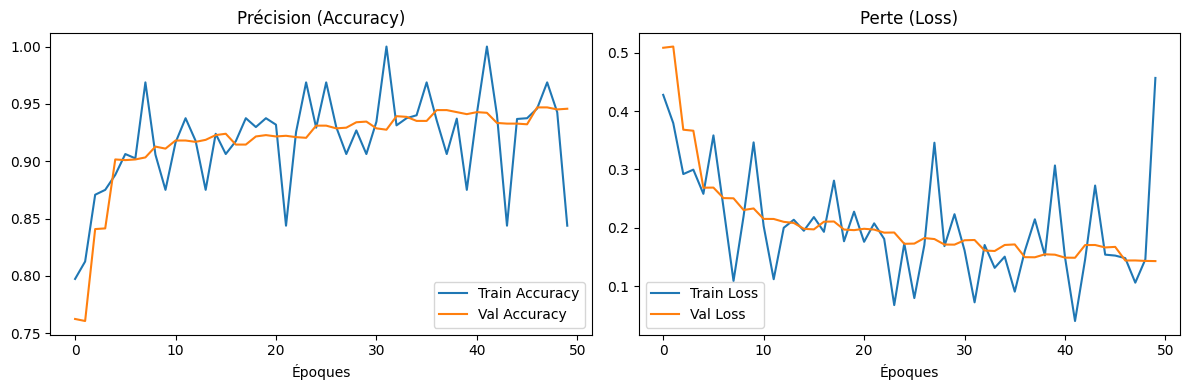

Précision de la classe 0 : 85.3%
Rappel de la classe 0 : 91.7%
Moyenne harmonique de la classe 0 : 88.4%
Précision de la classe 1 : 97.4%
Rappel de la classe 1 : 95.2%
Moyenne harmonique de la classe 1 : 96.3%
--> Suivi enregistré dans : ./Travail_IA/RESULTATS/recap_entrainement_Test_Thrips.txt
Fin de l'itération. Précision validée : 0.511

[SUCCÈS] Tout est terminé.
Retrouvez vos graphiques et le fichier recap_entrainement_Test_Thrips.txt dans : ./Travail_IA/RESULTATS


In [20]:
##############
# Lancement (Version Cohérente avec vos Variables)
##############

# On utilise FOLDER_IN pour les images et FOLDER_OUT pour les sauvegardes
for i in range(iterations):
    print(f"\n--- Itération #{i+1} ---")

    # 1. Lancement de l'entraînement
    # On passe FOLDER_IN (données) et FOLDER_OUT (destination des poids/csv)
    best_acc_file, best_loss_file, history_file = entrainement_mobilenet(FOLDER_IN, nb_epochs, FOLDER_OUT, id)

    if best_loss_file != 'None':
        # 2. AFFICHAGE DU GRAPHIQUE (La fonction Plot)
        # On utilise FOLDER_OUT car c'est là qu'est le fichier history_file (.csv)
        plot_history(history_file, FOLDER_OUT)

        # 3. ANALYSE (Matrice de confusion, etc.)
        # On analyse les images dans FOLDER_IN avec les poids dans FOLDER_OUT
        mat_confusion, report, report_moy, v_acc, v_loss = analyse_affectations_mobilenet_validation(FOLDER_IN, FOLDER_OUT, best_loss_file, history_file)

        # 4. SAUVEGARDE DU SUIVI LOCAL
        # On regroupe les informations pour le fichier texte
        infos_ia = {
            "Classes": classes,
            "Nb Epochs": nb_epochs,
            "Best Val Loss": v_loss,
            "Best Val Accuracy": v_acc,
            "Matrice de confusion": mat_confusion,
            "Fichier Poids": best_loss_file
        }

        # On appelle la fonction de sauvegarde (dans FOLDER_OUT)
        sauvegarde_suivi_local(FOLDER_OUT, id, infos_ia)

        print(f"Fin de l'itération. Précision validée : {v_acc}")
    else:
        print("Erreur : L'entraînement n'a pas généré de fichiers. Vérifiez vos chemins.")

print(f"\n[SUCCÈS] Tout est terminé.")
print(f"Retrouvez vos graphiques et le fichier recap_entrainement_{id}.txt dans : {FOLDER_OUT}")

In [ ]:
# ##############
# # Lancement { -------------------------------------------------------------------------------------------------------------------------------------------
# ##############

# id          = libelle
# FOLDER_SAVE = ROOT_FOLDER+"/"+libelle
# if os.path.exists(FOLDER_SAVE) == False:
#     os.makedirs(FOLDER_SAVE)

# #Récupération des noms des vignettes en base de données
# print("--> Requête MySQL initiale")
# dictionnaire = obtention_listes_nom_fichier_vignette(mysql_request)

# file_1 = open(FOLDER_SAVE+"/"+"Suivi_"+id+".txt", 'w+')
# file_1.write("%s : %s (%s)\nproportion_train = %s, proportion_test = %s, effectifs_train = %s, effectifs_validation = %s, effectifs_test = %s, coef = %s, FLAG_DA = %s, iterations = %s, nb_epochs = %s\n" % (id, classes, nb_classes, proportion_train, proportion_test, effectifs_train, effectifs_validation, effectifs_test, coef, FLAG_DA, iterations, nb_epochs))
# file_1.close
# file_2 = open(FOLDER_SAVE+"/Erreurs_"+id+".txt",'w+')
# file_2.write("nom_fichier_vignette,classe_predite,valeur_classe_predite,classe_reel,valeur_classe_reel\n")
# file_2.close
# file_3 = open(FOLDER_SAVE+"/JDD_"+id+".txt",'w+')
# file_3.write("train/validation/test\n")
# file_3.close

# #Validation croisée : toutes les étapes du développement de poids vont ensuite être itérées
# max_val_accuracy, min_val_loss, matrice_confusion, performances_par_classe, performances_moyenne, noms_poids, separateur = "", "", "", "", "", "", ";"
# for i in range(iterations):
#     print("\nItération #", i+1)

#     #Récupération des vignettes sur le disque dur et création des dossiers pour l'apprentissage
#     print("--> Séparation train/validation")
#     separation_entrainement_validation([[x for x in dictionnaire[j]] for j in range(nb_classes)], proportion_train, proportion_test, effectifs_train, effectifs_validation, effectifs_test, FOLDER_IN, FOLDER_OUT)

#     #Si demandé, on réalise une data-augmentation 'en dur' des vignettes.
#     if coef > 1:
#         print("--> Data-augmentation")
#         data_augmentation_vignettes_train(coef, FOLDER_OUT)

#     time_beginning=time.time()
#     #Apprentissage du modèle à partir des vignettes des dossiers d'entraînement et de validation
#     print("--> Entraînement MobileNet : %s classes %s" % (nb_classes, classes))
#     best_accuracy, best_loss, history = entrainement_mobilenet(FOLDER_OUT, nb_epochs, FOLDER_SAVE, id)
#     print("Temps total entraînement : %ss" % (time.time()-time_beginning))

#     time_beginning=time.time()
#     #Le modèle est de nouveau créé, puis chargé avec les poids obtenus précédemment (meilleure précision). Une inférence est réalisée sur le jeu de validation pour réaliser des classifications
#     print("--> Inférence")
#     # mat_confusion, mat_result, mat_result_moyenne, val_accuracy, val_loss = analyse_affectations_mobilenet_validation(FOLDER_OUT, FOLDER_SAVE, best_accuracy, history)
#     mat_confusion, mat_result, mat_result_moyenne, val_accuracy, val_loss = analyse_affectations_mobilenet_validation(FOLDER_OUT, FOLDER_SAVE, best_loss, history)
#     print("Temps total inférence : %ss" % (time.time()-time_beginning))

#     #Ajout jeu de données test 2024
#     if proportion_test != 0 or sum(effectifs_test) != 0:
#         time_beginning=time.time()
#         print("--> Test")
#         # mat_confusion_test, mat_result_test, mat_result_moyenne_test, confusion_05, result_classe_05, result_moyenne_05, confusion_06, result_classe_06, result_moyenne_06, confusion_07, result_classe_07, result_moyenne_07, confusion_08, result_classe_08, result_moyenne_08, confusion_09, result_classe_09, result_moyenne_09 = analyse_affectations_mobilenet_test(FOLDER_OUT, FOLDER_SAVE, best_accuracy)
#         mat_confusion_test, mat_result_test, mat_result_moyenne_test, confusion_05, result_classe_05, result_moyenne_05, confusion_06, result_classe_06, result_moyenne_06, confusion_07, result_classe_07, result_moyenne_07, confusion_08, result_classe_08, result_moyenne_08, confusion_09, result_classe_09, result_moyenne_09 = analyse_affectations_mobilenet_test(FOLDER_OUT, FOLDER_SAVE, best_loss)
#         print("Temps total test final : %ss" % (time.time()-time_beginning))


#     file_1 = open(FOLDER_SAVE+"/"+"Suivi_"+id+".txt", 'a+')
#     file_1.write("\nVALIDATION\n")
#     file_1.write("Iteration #%s\nmax_val_accuracy = %s\nmin_val_loss = %s\nCONFUSION\n%s\nPrécision/Rappel/F-mesure par classe\n%s\nPrécision/Rappel/F-mesure moyenne\n%s\n[%s / %s / %s]\n" % (i, val_accuracy, val_loss, mat_confusion, mat_result, mat_result_moyenne, best_accuracy, best_loss, history))
#     file_1.write("\nTEST\n")
#     file_1.write("CONFUSION\n%s\nPrécision/Rappel/F-mesure par classe\n%s\nPrécision/Rappel/F-mesure moyenne\n%s\n" % (mat_confusion_test, mat_result_test, mat_result_moyenne_test))
#     file_1.write("\nTEST SEUIL DE DECISION 0.5\n")
#     file_1.write("CONFUSION\n%s\nPrécision/Rappel/F-mesure par classe\n%s\nPrécision/Rappel/F-mesure moyenne\n%s\n" % (confusion_05, result_classe_05, result_moyenne_05))
#     file_1.write("\nTEST SEUIL DE DECISION 0.6\n")
#     file_1.write("CONFUSION\n%s\nPrécision/Rappel/F-mesure par classe\n%s\nPrécision/Rappel/F-mesure moyenne\n%s\n" % (confusion_06, result_classe_06, result_moyenne_06))
#     file_1.write("\nTEST SEUIL DE DECISION 0.7\n")
#     file_1.write("CONFUSION\n%s\nPrécision/Rappel/F-mesure par classe\n%s\nPrécision/Rappel/F-mesure moyenne\n%s\n" % (confusion_07, result_classe_07, result_moyenne_07))
#     file_1.write("\nTEST SEUIL DE DECISION 0.8\n")
#     file_1.write("CONFUSION\n%s\nPrécision/Rappel/F-mesure par classe\n%s\nPrécision/Rappel/F-mesure moyenne\n%s\n" % (confusion_08, result_classe_08, result_moyenne_08))
#     file_1.write("\nTEST SEUIL DE DECISION 0.9\n")
#     file_1.write("CONFUSION\n%s\nPrécision/Rappel/F-mesure par classe\n%s\nPrécision/Rappel/F-mesure moyenne\n%s\n" % (confusion_09, result_classe_09, result_moyenne_09))
#     file_1.close
#     file_2 = open(FOLDER_SAVE+"/"+"Erreurs_"+id+".txt", 'a+')
#     file_2.write("\n\n")
#     file_2.close

#     #Validation croisée : informations sur l'entraînement pour `dataset`
#     if i+1 == iterations:
#         separateur = ""
#     max_val_accuracy        = max_val_accuracy + val_accuracy + separateur
#     min_val_loss            = min_val_loss + val_loss + separateur
#     matrice_confusion       = matrice_confusion + mat_confusion + separateur
#     performances_par_classe = performances_par_classe + mat_result + separateur
#     performances_moyenne    = performances_moyenne + mat_result_moyenne + separateur
#     noms_poids              = noms_poids + "["+best_accuracy+" "+best_loss+"]" + separateur

# file_1 = open(FOLDER_SAVE+"/"+"Suivi_"+id+".txt", 'a+')
# file_1.write("\n")
# file_1.close

# #Toutes les infos utiles sont ensuite renseignées dans la table `dataset`
# print("--> Sauvegarde informations dataset")
# remplissage_table_dataset(libelle, str(classes), nb_classes, mysql_request, max_val_accuracy, min_val_loss, matrice_confusion, performances_par_classe, performances_moyenne, noms_poids, str(proportion_train)+";"+str(proportion_test)+";"+str(effectifs_train)+";"+str(effectifs_validation)+";"+str(effectifs_test), coef, FLAG_DA, iterations, nb_epochs, 1)

# file_1 = open(FOLDER_SAVE+"/"+"Suivi_"+id+".txt", 'a+')
# file_1.write("\n")
# file_1.close

# #Enfin les vignettes utilisées sont sauvegardés dans une table de jointure
# print("--> Sauvegarde jeu de données")
# creation_table_jointure_vignette_dataset(dictionnaire)

# file_1 = open(FOLDER_SAVE+"/"+"Suivi_"+id+".txt", 'a+')
# file_1.write("\n")
# file_1.close
# ##############
# # Lancement } -------------------------------------------------------------------------------------------------------------------------------------------
# ##############